In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from matplotlib.patches import Arc, FancyArrowPatch

In [65]:
tariff = pd.read_csv('Data/ustariffs-by-county.csv')
zillow = pd.read_csv('Data/zillow county.csv')

In [66]:
tariff_columns_drop = ['Unnamed: 0','total_imp_pc','china_imp_pc','emplvl_2017','total_employment','int_area_fips','2017_income','area_fips']
tariff = tariff.drop(columns = tariff_columns_drop)

In [67]:
tariff['time'] = pd.to_datetime(tariff['time'])

In [68]:
tariff = tariff[(tariff['time'] >= '2017-01-01') & (tariff['time'] <= '2019-12-31')]

In [69]:
# First create your pivoted tariff DataFrame
pivoted_tariff = tariff.pivot(index='fips', columns='time', values='tariff')

population_data = tariff.dropna(subset=['2017_population']).drop_duplicates(subset=['fips'], keep='first')[['fips', '2017_population']]

# Set fips as index to allow joining
population_data = population_data.set_index('fips')

# Join the population data to the pivoted tariff DataFrame
pivoted_tariff = pivoted_tariff.join(population_data)

In [70]:


# Get the current column names (excluding 'fips' which is the index)
current_columns = pivoted_tariff.columns.tolist()

# Create a dictionary to map current column names to new column names
column_mapping = {}

for col in current_columns:
    if isinstance(col, str) and '-' in col:  # Check if it's a date string
        try:
            # Parse the current date (e.g., '2017-01-01')
            current_date = pd.to_datetime(col)
            
            # Calculate the last day of the previous month
            # Subtract 1 day from the current date (which is the 1st of a month)
            new_date = current_date - timedelta(days=1)
            
            # Format the new date as a string (e.g., '2016-12-31')
            new_date_str = new_date.strftime('%Y-%m-%d')
            
            # Add to mapping
            column_mapping[col] = new_date_str
        except:
            # If there's an error in parsing, keep the original column name
            column_mapping[col] = col
    else:
        # For non-date columns (like 'change' if it exists), keep the original name
        column_mapping[col] = col

# Rename the columns
pivoted_tariff = pivoted_tariff.rename(columns=column_mapping).reset_index()

In [71]:
first_date = pivoted_tariff.columns[1]  
last_date = pivoted_tariff.columns[-2]  

# Calculate the change
pivoted_tariff['tariff_change'] = pivoted_tariff[last_date] - pivoted_tariff[first_date]

In [72]:
# Convert StateCodeFIPS and MunicipalCodeFIPS to strings
zillow['StateCodeFIPS'] = zillow['StateCodeFIPS'].astype(str).str.zfill(2)
zillow['MunicipalCodeFIPS'] = zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)

# Concatenate the two codes to create the full 5-digit FIPS code
zillow['fips'] = zillow['StateCodeFIPS'] + zillow['MunicipalCodeFIPS']

# If you want the fips as an integer instead of a string
zillow['fips'] = zillow['fips'].astype(int)

In [73]:
zillow_drop_columns = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','Metro','StateCodeFIPS','MunicipalCodeFIPS']
zillow = zillow.drop(columns = zillow_drop_columns)

In [74]:
all_columns = zillow.columns.tolist()

# Keep only the 'fips' column and date columns between 2017 and 2019
columns_to_keep = ['fips']  # Start with 'fips'

# Add date columns between 2017 and 2019
for column in all_columns:
    # Check if the column name is a date string (assuming format 'YYYY-MM-DD')
    if isinstance(column, str) and len(column) == 10 and column[4] == '-' and column[7] == '-':
        try:
            year = int(column.split('-')[0])
            if 2017 <= year <= 2019:
                columns_to_keep.append(column)
        except:
            pass

# Filter the DataFrame to keep only the selected columns
zillow_filtered = zillow[columns_to_keep]

In [75]:
# Convert columns to numeric first (if needed)
# Then calculate percentage change between last and first columns
zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_36367/1705049525.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100


In [76]:
zillow_filtered = zillow_filtered[['fips','change']].dropna()
# Drop all rows containing any NaN values and create a new DataFrame
tariff_filtered = pivoted_tariff[['fips','tariff_change','2017_population']]

scatter_data = zillow_filtered.merge(tariff_filtered,how = 'inner',left_on = 'fips',right_on = 'fips')

In [77]:
scatter_data = scatter_data.dropna()

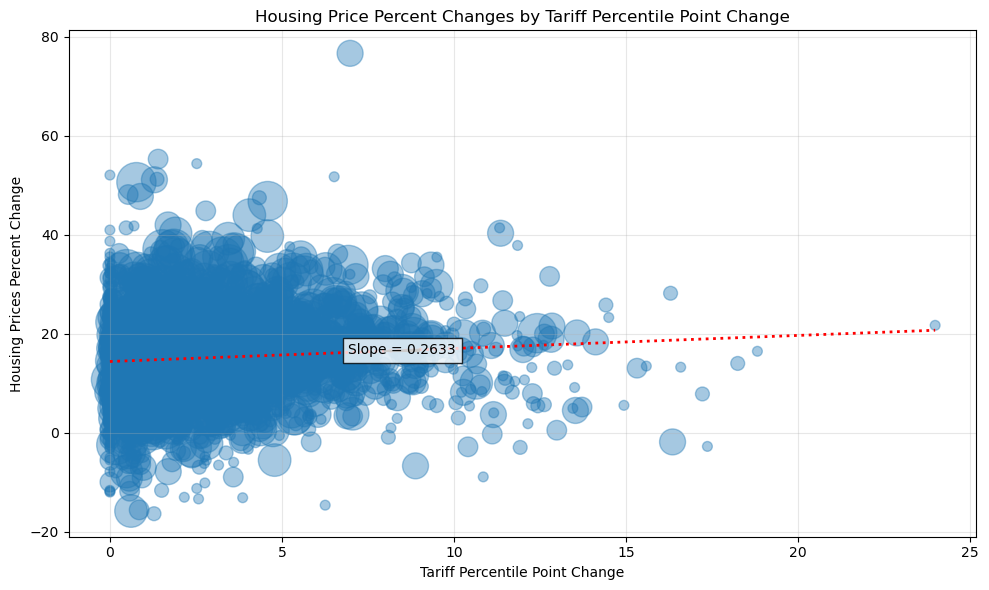

Plot saved to Images/Scatterplot.png


In [78]:
import matplotlib.pyplot as plt
import numpy as np
import os

y = scatter_data['change']
x = scatter_data['tariff_change']
populations = scatter_data['2017_population']
# Create 6 distinct size categories using population percentiles
population_bins = np.percentile(populations, [0, 16.6, 33.3, 50, 66.6, 83.3, 100])
size_values = [50, 100, 200, 350, 550, 800]  # 6 distinct sizes with good separation
# Assign each data point to a size category
sizes = np.zeros_like(populations, dtype=float)
for i in range(len(population_bins)-1):
    mask = (populations >= population_bins[i]) & (populations <= population_bins[i+1])
    sizes[mask] = size_values[i]
    
# Create the scatter plot with sized points
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=sizes, alpha=0.4)  # alpha adds transparency to see overlapping points

# Calculate and add the line of best fit
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([min(x), max(x)])
y_line = slope * x_line + intercept

# Plot the best fit line as dotted
ax.plot(x_line, y_line, color='red', linestyle='dotted', linewidth=2, 
         label=f'y = {slope:.4f}x + {intercept:.4f}')

# Create a slope marker
# Choose a point along the line (1/3 from the left)
x_marker = x_line[0] + (x_line[1] - x_line[0]) / 3
y_marker = slope * x_marker + intercept

# Create a triangle to represent the slope
dx = 1.0  # Width of the slope marker
dy = dx * slope  # Height change over that width

# Draw the slope triangle
ax.plot([x_marker, x_marker + dx], [y_marker, y_marker], 'k-', linewidth=1.5)  # Horizontal line
ax.plot([x_marker + dx, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)  # Vertical line
ax.plot([x_marker, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)  # Hypotenuse

# Add slope text
ax.text(x_marker + dx/2, y_marker + dy/2, f'Slope = {slope:.4f}', 
         ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
ax.set_xlabel('Tariff Percentile Point Change') 
ax.set_ylabel('Housing Prices Percent Change')
ax.set_title('Housing Price Percent Changes by Tariff Percentile Point Change')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Make sure the Images directory exists
os.makedirs('Images', exist_ok=True)

# Define the output path
output_path = os.path.join('Images', 'Scatterplot.png')

# Save the figure first, before showing it
plt.savefig(output_path, 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1)

# Now show the plot (after saving)
plt.show()

print(f"Plot saved to {output_path}")

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_65026/2181121185.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100


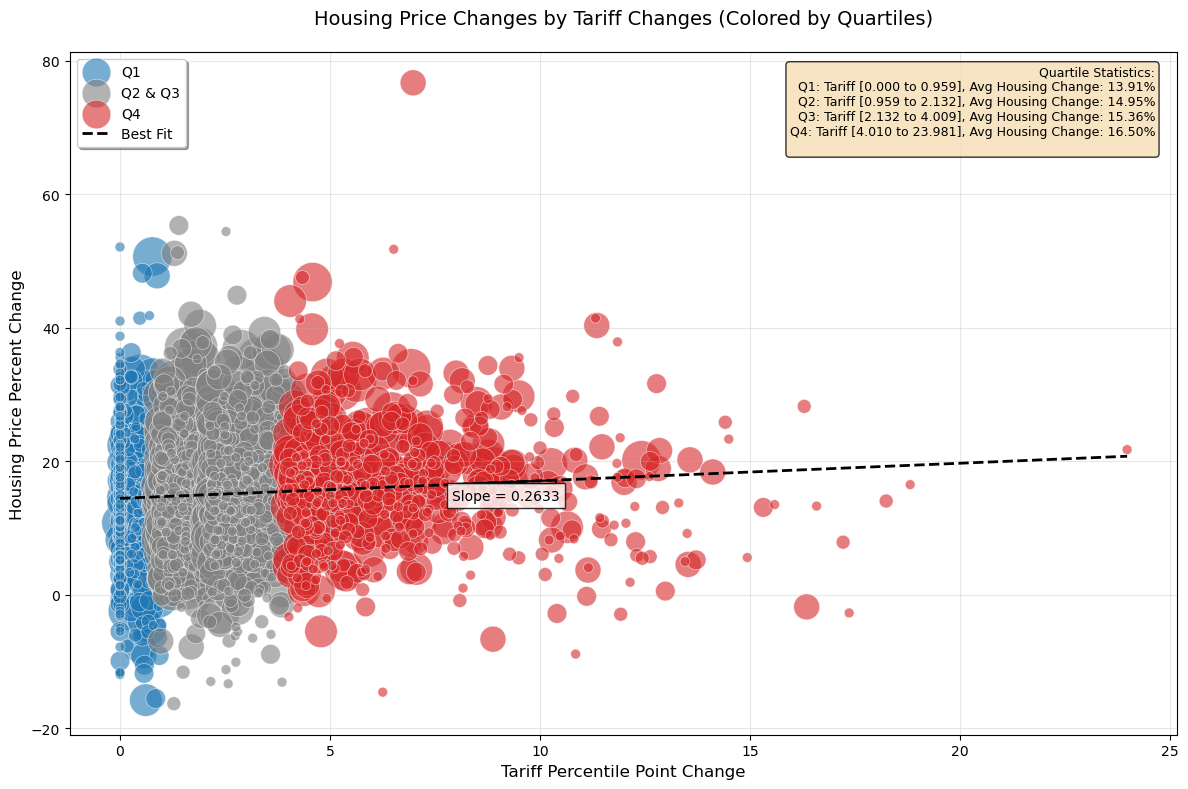

Quartile-colored scatterplot saved to Images/Quartile_Scatterplot.png

Quartile distribution:
Q1    742
Q2    741
Q3    741
Q4    742
Name: quartile, dtype: int64


In [24]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime, timedelta

# Load the data
tariff = pd.read_csv('Data/ustariffs-by-county.csv')
zillow = pd.read_csv('Data/zillow county.csv')

# Clean tariff data
tariff_columns_drop = ['Unnamed: 0','total_imp_pc','china_imp_pc','emplvl_2017','total_employment','int_area_fips','2017_income','area_fips']
tariff = tariff.drop(columns=tariff_columns_drop)

# Convert time column and filter date range
tariff['time'] = pd.to_datetime(tariff['time'])
tariff = tariff[(tariff['time'] >= '2017-01-01') & (tariff['time'] <= '2019-12-31')]

# Create pivoted tariff DataFrame
pivoted_tariff = tariff.pivot(index='fips', columns='time', values='tariff')

# Add population data
population_data = tariff.dropna(subset=['2017_population']).drop_duplicates(subset=['fips'], keep='first')[['fips', '2017_population']]
population_data = population_data.set_index('fips')
pivoted_tariff = pivoted_tariff.join(population_data)

# Rename columns to shift dates back by one day (to match original logic)
current_columns = pivoted_tariff.columns.tolist()
column_mapping = {}

for col in current_columns:
    if isinstance(col, str) and '-' in col:  # Check if it's a date string
        try:
            current_date = pd.to_datetime(col)
            new_date = current_date - timedelta(days=1)
            new_date_str = new_date.strftime('%Y-%m-%d')
            column_mapping[col] = new_date_str
        except:
            column_mapping[col] = col
    else:
        column_mapping[col] = col

pivoted_tariff = pivoted_tariff.rename(columns=column_mapping).reset_index()

# Calculate tariff change
first_date = pivoted_tariff.columns[1]  
last_date = pivoted_tariff.columns[-2]  
pivoted_tariff['tariff_change'] = pivoted_tariff[last_date] - pivoted_tariff[first_date]

# Process Zillow data
# Create FIPS code
zillow['StateCodeFIPS'] = zillow['StateCodeFIPS'].astype(str).str.zfill(2)
zillow['MunicipalCodeFIPS'] = zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
zillow['fips'] = zillow['StateCodeFIPS'] + zillow['MunicipalCodeFIPS']
zillow['fips'] = zillow['fips'].astype(int)

# Drop unnecessary columns
zillow_drop_columns = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','Metro','StateCodeFIPS','MunicipalCodeFIPS']
zillow = zillow.drop(columns=zillow_drop_columns)

# Keep only fips and date columns between 2017 and 2019
all_columns = zillow.columns.tolist()
columns_to_keep = ['fips']

for column in all_columns:
    if isinstance(column, str) and len(column) == 10 and column[4] == '-' and column[7] == '-':
        try:
            year = int(column.split('-')[0])
            if 2017 <= year <= 2019:
                columns_to_keep.append(column)
        except:
            pass

zillow_filtered = zillow[columns_to_keep]

# Calculate housing price percentage change
zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100

# Prepare final datasets
zillow_filtered = zillow_filtered[['fips','change']].dropna()
tariff_filtered = pivoted_tariff[['fips','tariff_change','2017_population']]

# Merge the datasets
scatter_data = zillow_filtered.merge(tariff_filtered, how='inner', left_on='fips', right_on='fips')
scatter_data = scatter_data.dropna()

# CREATE QUARTILES USING METHOD 2 (pandas qcut)
scatter_data['quartile'] = pd.qcut(scatter_data['tariff_change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Define colors for each quartile
quartile_colors = {
    'Q1': '#1f77b4',    # Blue for Q1 (highest tariff changes)
    'Q2': '#808080',    # Gray for Q2 and Q3 (middle quartiles)
    'Q3': '#808080',    # Gray for Q2 and Q3 (middle quartiles)  
    'Q4': '#d62728'     # Red for Q4 (lowest tariff changes)
}

# Map colors to each data point
colors = scatter_data['quartile'].map(quartile_colors)

# Prepare data for plotting
y = scatter_data['change']
x = scatter_data['tariff_change']
populations = scatter_data['2017_population']

# Create 6 distinct size categories using population percentiles
population_bins = np.percentile(populations, [0, 16.6, 33.3, 50, 66.6, 83.3, 100])
size_values = [50, 100, 200, 350, 550, 800]

# Assign each data point to a size category
sizes = np.zeros_like(populations, dtype=float)
for i in range(len(population_bins)-1):
    mask = (populations >= population_bins[i]) & (populations <= population_bins[i+1])
    sizes[mask] = size_values[i]

# Create the scatter plot with quartile colors
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each quartile separately for better legend control
legend_labels_added = set()
for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
    mask = scatter_data['quartile'] == quartile
    
    if quartile in ['Q2', 'Q3']:
        # Combine Q2 and Q3 in legend
        if 'Q2 & Q3' not in legend_labels_added:
            label = 'Q2 & Q3'
            legend_labels_added.add('Q2 & Q3')
        else:
            label = None
    else:
        label = f'{quartile}'
    
    ax.scatter(x[mask], y[mask], s=sizes[mask], 
               c=quartile_colors[quartile], alpha=0.6, 
               label=label, edgecolors='white', linewidth=0.5)

# Calculate and add the line of best fit
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([min(x), max(x)])
y_line = slope * x_line + intercept

# Plot the best fit line as dotted
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=2, 
         label='Best Fit')

# Create a slope marker
x_marker = x_line[0] + (x_line[1] - x_line[0]) / 3
y_marker = slope * x_marker + intercept

# Draw the slope triangle
dx = (max(x) - min(x)) * 0.1
dy = dx * slope

ax.plot([x_marker, x_marker + dx], [y_marker, y_marker], 'k-', linewidth=1.5)
ax.plot([x_marker + dx, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)
ax.plot([x_marker, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)

# Add slope text
ax.text(x_marker + dx/2, y_marker + dy/2 - 2, f'Slope = {slope:.4f}', 
         ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Customize the plot
ax.set_xlabel('Tariff Percentile Point Change', fontsize=12)
ax.set_ylabel('Housing Price Percent Change', fontsize=12)
ax.set_title('Housing Price Changes by Tariff Changes (Colored by Quartiles)', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)

# Add quartile statistics as text box
quartile_stats = scatter_data.groupby('quartile').agg({
    'tariff_change': ['min', 'max', 'mean'],
    'change': 'mean'
}).round(3)

stats_text = "Quartile Statistics:\n"
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    tariff_range = f"{quartile_stats.loc[q, ('tariff_change', 'min')]:.3f} to {quartile_stats.loc[q, ('tariff_change', 'max')]:.3f}"
    housing_mean = quartile_stats.loc[q, ('change', 'mean')]
    stats_text += f"{q}: Tariff [{tariff_range}], Avg Housing Change: {housing_mean:.2f}%\n"

ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

# Save the plot
os.makedirs('Images', exist_ok=True)
output_path = os.path.join('Images', 'Quartile_Scatterplot.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f"Quartile-colored scatterplot saved to {output_path}")
print(f"\nQuartile distribution:")
print(scatter_data['quartile'].value_counts().sort_index())

In [41]:
# Find the county with the highest housing price change
max_change_idx = scatter_data['change'].idxmax()
max_change_county = scatter_data.loc[max_change_idx]

print(f"\nCounty with the highest housing price change:")
print(f"FIPS Code: {max_change_county['fips']}")
print(f"Housing Price Change: {max_change_county['change']:.2f}%")
print(f"Tariff Change: {max_change_county['tariff_change']:.4f}")
print(f"2017 Population: {max_change_county['2017_population']:,.0f}")
print(f"Quartile: {max_change_county['quartile']}")


County with the highest housing price change:
FIPS Code: 26165
Housing Price Change: 76.69%
Tariff Change: 6.9799
2017 Population: 32,915
Quartile: Q4
